# Analyse en composantes principales — Agriculture CropYield

**Objectif** : analyser la structure multivariée du dataset et identifier les variables qui
portent l'essentiel de la variance.

- Données : `data/agriculture-crop-yield/crop_yield.csv`, 1 000 000 de lignes.
- Une ligne = une parcelle sur une saison.
- Principe : ACP sur les variables quantitatives, centrées-réduites, ajustée sur l'ensemble
  des lignes.

# Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from agritech.config import AGRICULTURE_CROP_YIELD_FILENAME, PATHS, SEED

sns.set()

# Données

In [2]:
csv_path = PATHS.data_agriculture_crop_yield / AGRICULTURE_CROP_YIELD_FILENAME
df = pd.read_csv(csv_path)
print(f"{df.shape[0]:,} lignes x {df.shape[1]} colonnes".replace(",", " "))
df.head()

1 000 000 lignes x 10 colonnes


,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
0,West,Sandy,Cotton,897.077239,27.676966,False,True,Cloudy,122,6.555816
1,South,Clay,Rice,992.673282,18.026142,True,True,Rainy,140,8.527341
2,North,Loam,Barley,147.998025,29.794042,False,False,Sunny,106,1.127443
3,North,Sandy,Soybean,986.866331,16.644190,False,True,Rainy,146,6.517573
4,South,Silt,Wheat,730.379174,31.620687,True,True,Cloudy,110,7.248251


Les 231 rendements négatifs identifiés lors de l'EDA (0,023 % des lignes) sont conservés à ce
stade.

# Préparation des données

## Variables retenues

L'ACP porte sur des variables quantitatives. Les 4 variables nominales — `Region`,
`Soil_Type`, `Crop`, `Weather_Condition` — sont écartées : leur attribuer des valeurs
numériques créerait de fausses distances. Elles sont examinées dans l'EDA.

**Choix retenus**

- `Fertilizer_Used`, `Irrigation_Used` : booléens convertis en 0/1, puis standardisés avec les
  autres variables.
- `Days_to_Harvest` : conservée pour analyser sa place dans la structure globale.
- `Yield_tons_per_hectare` : conservée pour observer sa relation avec les autres variables
  dans cette analyse exploratoire.

Le rendement devrait en revanche être écarté si l'ACP servait de prétraitement à un modèle
supervisé, sous peine de fuite de données.

In [3]:
pca_cols = [
    "Rainfall_mm",
    "Temperature_Celsius",
    "Fertilizer_Used",
    "Irrigation_Used",
    "Days_to_Harvest",
    "Yield_tons_per_hectare",
]

X = df[pca_cols].astype(float)  # convertit les deux booléens en 0.0 / 1.0

print("valeurs manquantes :", X.isna().sum().sum())
print("dimensions         :", X.shape)
X.head()

valeurs manquantes : 0
dimensions         : (1000000, 6)


,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Days_to_Harvest,Yield_tons_per_hectare
0,897.077239,27.676966,0.0,1.0,122.0,6.555816
1,992.673282,18.026142,1.0,1.0,140.0,8.527341
2,147.998025,29.794042,0.0,0.0,106.0,1.127443
3,986.866331,16.644190,0.0,1.0,146.0,6.517573
4,730.379174,31.620687,1.0,1.0,110.0,7.248251


## Corrélations de départ

L'ACP s'appuie sur les relations linéaires entre les variables retenues.

In [4]:
X.corr().round(3)

,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Days_to_Harvest,Yield_tons_per_hectare
Rainfall_mm,1.000,-0.000,-0.001,-0.001,-0.003,0.765
Temperature_Celsius,-0.000,1.000,0.002,-0.000,-0.001,0.086
Fertilizer_Used,-0.001,0.002,1.000,0.002,-0.001,0.442
Irrigation_Used,-0.001,-0.000,0.002,1.000,-0.001,0.354
Days_to_Harvest,-0.003,-0.001,-0.001,-0.001,1.000,-0.003
Yield_tons_per_hectare,0.765,0.086,0.442,0.354,-0.003,1.000


**Observations :**

- Les cinq variables d'entrée sont très peu corrélées entre elles : |r| ≤ 0,003.
- La seule structure passe par le rendement : pluie 0,765 · engrais 0,442 · irrigation 0,354 ·
  température 0,086.
- `Days_to_Harvest` : aucune relation linéaire visible, y compris avec le rendement (−0,003).

## Standardisation

Échelles hétérogènes : pluie jusqu'à 1 000 mm, booléens à 0/1. L'ACP maximisant la variance,
les variables sont centrées-réduites pour peser le même poids.

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pd.DataFrame(X_scaled, columns=pca_cols).describe().round(2).loc[["mean", "std"], :]

,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Days_to_Harvest,Yield_tons_per_hectare
mean,-0.0,-0.0,-0.0,-0.0,0.0,0.0
std,1.0,1.0,1.0,1.0,1.0,1.0


**Observations :**

- Moyenne 0 et écart-type 1 pour les 6 variables.

# ACP

ACP calculée avec toutes les composantes disponibles, sur l'ensemble des lignes.

In [6]:
n_components = X.shape[1]
axes_noms = [f"F{i}" for i in range(1, n_components + 1)]

pca = PCA(n_components=n_components)
pca.fit(X_scaled)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",6
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD 

## Variance expliquée

In [7]:
scree = (pca.explained_variance_ratio_ * 100).round(2)
scree_cum = scree.cumsum().round(2)

pd.DataFrame(
    {
        "valeur propre": pca.explained_variance_.round(3),
        "variance expliquée (%)": scree,
        "variance cumulée (%)": scree_cum,
    },
    index=axes_noms,
)

,valeur propre,variance expliquée (%),variance cumulée (%)
F1,1.955,32.58,32.58
F2,1.003,16.71,49.29
F3,1.001,16.68,65.97
F4,1.000,16.67,82.64
F5,0.997,16.62,99.26
F6,0.044,0.74,100.00


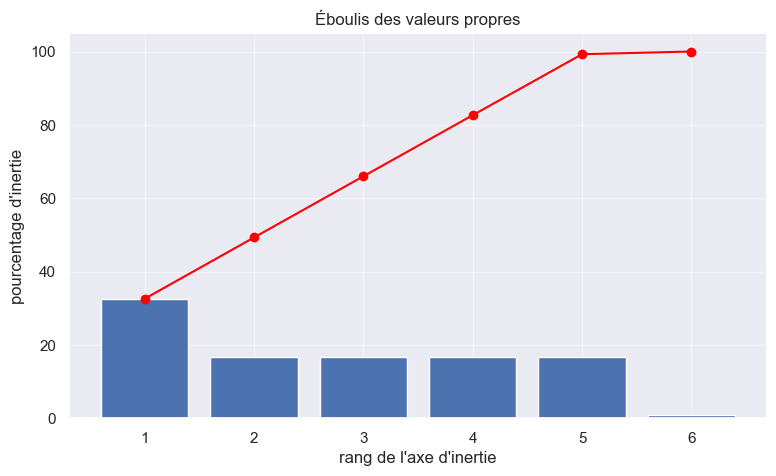

In [8]:
x_list = range(1, n_components + 1)

plt.figure(figsize=(9, 5))
plt.bar(x_list, scree)
plt.plot(x_list, scree_cum, c="red", marker="o")
plt.xlabel("rang de l'axe d'inertie")
plt.ylabel("pourcentage d'inertie")
plt.title("Éboulis des valeurs propres")
plt.show()

**Observations :**

- F1 : 32,58 %, valeur propre 1,955 — seul axe qui se détache.
- F2 à F5 : 16,62 à 16,71 % chacun, valeurs propres proches de 1 — plateau, aucun axe ne
  ressort.
- F6 : 0,74 %, valeur propre 0,044.
- Cumul : 49 % à 2 axes, 66 % à 3, 99 % à 5. La compression est faible.

## Contrôle sans la cible

In [9]:
cols_sans_cible = [c for c in pca_cols if c != "Yield_tons_per_hectare"]

X_sans_cible = StandardScaler().fit_transform(df[cols_sans_cible].astype(float))
pca_sans_cible = PCA().fit(X_sans_cible)

pd.DataFrame(
    {"variance expliquée (%)": (pca_sans_cible.explained_variance_ratio_ * 100).round(2)},
    index=[f"F{i}" for i in range(1, len(cols_sans_cible) + 1)],
).T

,F1,F2,F3,F4,F5
variance expliquée (%),20.07,20.05,20.01,19.94,19.93


**Observations :**

- Environ 20 % de variance par composante, aucun axe dominant.
- Les variables explicatives sont peu corrélées entre elles et apportent des dimensions
  largement distinctes.
- L'ACP a donc peu d'intérêt comme réduction de dimension avant modélisation.

# Interprétation des axes
`components_` donne le coefficient de chaque variable dans chaque composante.


In [10]:
pcs = pd.DataFrame(pca.components_, columns=pca_cols, index=axes_noms)
pcs.round(3)

,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Days_to_Harvest,Yield_tons_per_hectare
F1,0.566,0.064,0.327,0.262,-0.004,0.707
F2,-0.544,0.478,0.634,0.267,0.043,-0.001
F3,-0.222,-0.632,-0.012,0.649,0.361,0.001
F4,0.103,0.105,0.101,-0.368,0.913,0.003
F5,-0.063,-0.594,0.611,-0.485,-0.188,0.000
F6,-0.566,-0.063,-0.327,-0.262,-0.000,0.707


## Corrélations variables / axes

Corrélation d'une variable avec un axe = loading × racine de la valeur propre ; c'est la
quantité utilisée pour interpréter les axes et tracer le cercle.

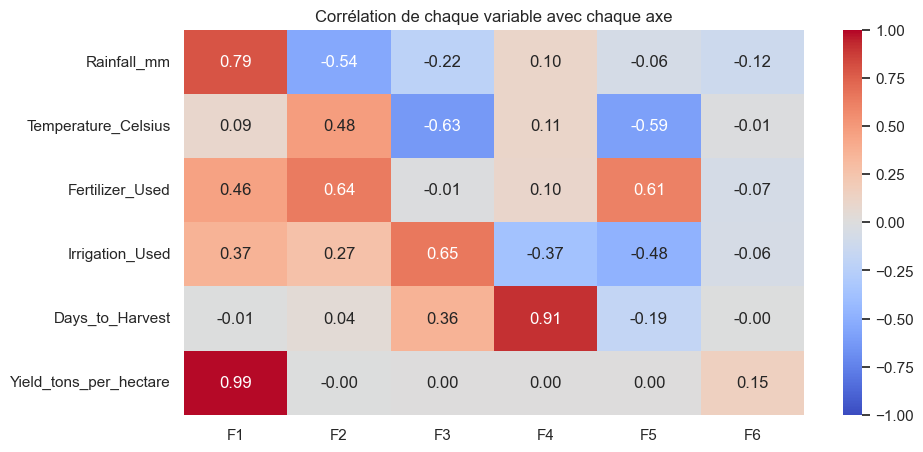

In [11]:
correlations = pcs.T * np.sqrt(pca.explained_variance_)

plt.figure(figsize=(10, 5))
sns.heatmap(correlations, vmin=-1, vmax=1, annot=True, fmt="0.2f", cmap="coolwarm")
plt.title("Corrélation de chaque variable avec chaque axe")
plt.show()

**Observations :**

- F1 : rendement 0,99 · pluie 0,79 · engrais 0,46 · irrigation 0,37 · température 0,09 —
  toutes de même signe.
- Le rendement est très fortement associé à F1.
- `Days_to_Harvest` : −0,01 sur F1 et 0,91 sur F4. Elle occupe un axe du plateau, à l'écart de
  la structure principale.

## Cercle des corrélations

In [12]:
def cercle_des_correlations(correlations, x_y):
    """Trace le cercle des corrélations pour le plan (Fx, Fy)."""
    x, y = x_y
    couleurs = sns.color_palette("tab10", len(correlations))
    fig, ax = plt.subplots(figsize=(7, 7))

    for (nom, (cx, cy)), couleur in zip(correlations.iloc[:, [x, y]].iterrows(), couleurs):
        # annotate place la pointe exactement sur (cx, cy) : la flèche ne déborde pas du cercle
        ax.annotate(
            "",
            xy=(cx, cy),
            xytext=(0, 0),
            arrowprops=dict(arrowstyle="-|>", color=couleur, lw=2, shrinkA=0, shrinkB=0),
        )
        # Le label est décalé au-delà de la pointe, dans la direction de la flèche
        norme = np.hypot(cx, cy)
        k = (norme + 0.10) / norme if norme > 0.15 else 0.20 / max(norme, 1e-9)
        ax.text(
            cx * k, cy * k, nom,
            color=couleur, fontsize=9, fontweight="bold",
            ha="left" if cx >= 0 else "right", va="center",
            bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.7),
        )

    angles = np.linspace(0, 2 * np.pi, 200)
    ax.plot(np.cos(angles), np.sin(angles), color="grey", lw=1)
    ax.axhline(0, color="grey", ls="--", lw=0.8)
    ax.axvline(0, color="grey", ls="--", lw=0.8)
    ax.set_xlabel(f"F{x + 1} ({scree[x]} %)")
    ax.set_ylabel(f"F{y + 1} ({scree[y]} %)")
    ax.set_title(f"Cercle des corrélations — F{x + 1} et F{y + 1}")
    ax.set_aspect("equal")
    ax.set_xlim(-1.6, 1.6)
    ax.set_ylim(-1.25, 1.25)
    plt.show()

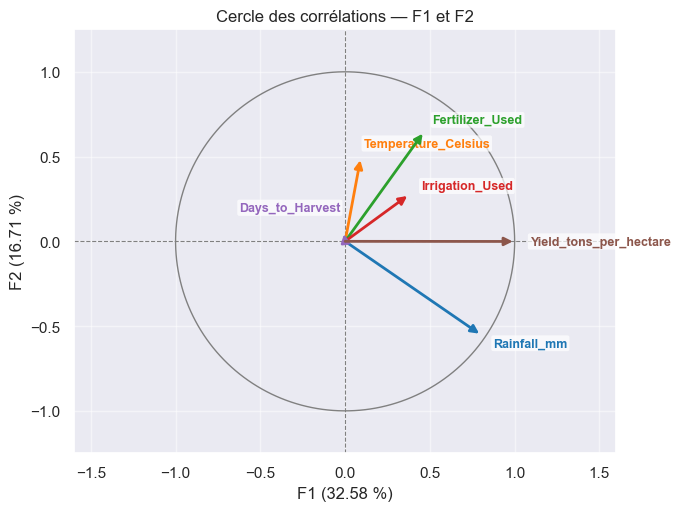

In [13]:
cercle_des_correlations(correlations, (0, 1))

**Observations :**

- `Yield_tons_per_hectare` : flèche horizontale proche du cercle — très fortement associée à F1.
- Pluie, engrais et irrigation pointent du même côté que le rendement.
- L'écartement vertical relève de F2, dont l'inertie ne se distingue pas de celle de F3 à F5 :
  à ne pas lire comme une opposition entre l'eau et les intrants.
- `Days_to_Harvest` : flèche très courte, mal représentée dans ce plan — elle est portée par F4.

# Projection des individus

Échantillon de 5 000 lignes (`random_state=SEED`) pour la lisibilité des nuages. L'ACP reste
ajustée sur l'ensemble des lignes.

In [14]:
X_proj = pca.transform(X_scaled)
proj = pd.DataFrame(X_proj, columns=axes_noms, index=df.index)

idx = df.sample(5_000, random_state=SEED).index
ech = proj.loc[idx]

# Une séparation des cultures sur un plan supposerait des coordonnées moyennes distinctes
moyennes_par_culture = proj.groupby(df["Crop"]).mean()

pd.DataFrame(
    {
        "écart max entre cultures": (moyennes_par_culture.max() - moyennes_par_culture.min()),
        "écart-type des individus": proj.std(),
    }
).T.round(3)

,F1,F2,F3,F4,F5,F6
écart max entre cultures,0.010,0.005,0.008,0.006,0.006,0.002
écart-type des individus,1.398,1.001,1.000,1.000,0.998,0.211


**Observations :**

- Les coordonnées moyennes des cultures sont très proches sur les 6 axes.
- Aucune séparation nette entre les cultures n'apparaît sur les plans factoriels examinés.

In [15]:
def plan_factoriel(x, y, groupes):
    """Projette l'échantillon sur le plan (Fx, Fy), une coloration par sous-graphe."""
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    for ax, (couleurs, titre) in zip(axes, groupes):
        sns.scatterplot(x=ech[f"F{x}"], y=ech[f"F{y}"], hue=couleurs, s=10, alpha=0.6, ax=ax)
        ax.axhline(0, color="grey", lw=0.8)
        ax.axvline(0, color="grey", lw=0.8)
        ax.set_xlabel(f"F{x} ({scree[x - 1]} %)")
        ax.set_ylabel(f"F{y} ({scree[y - 1]} %)")
        ax.set_title(titre)
        ax.legend(fontsize=8)

    fig.suptitle(f"Plan factoriel F{x}-F{y} — 5 000 parcelles")
    fig.tight_layout()
    plt.show()

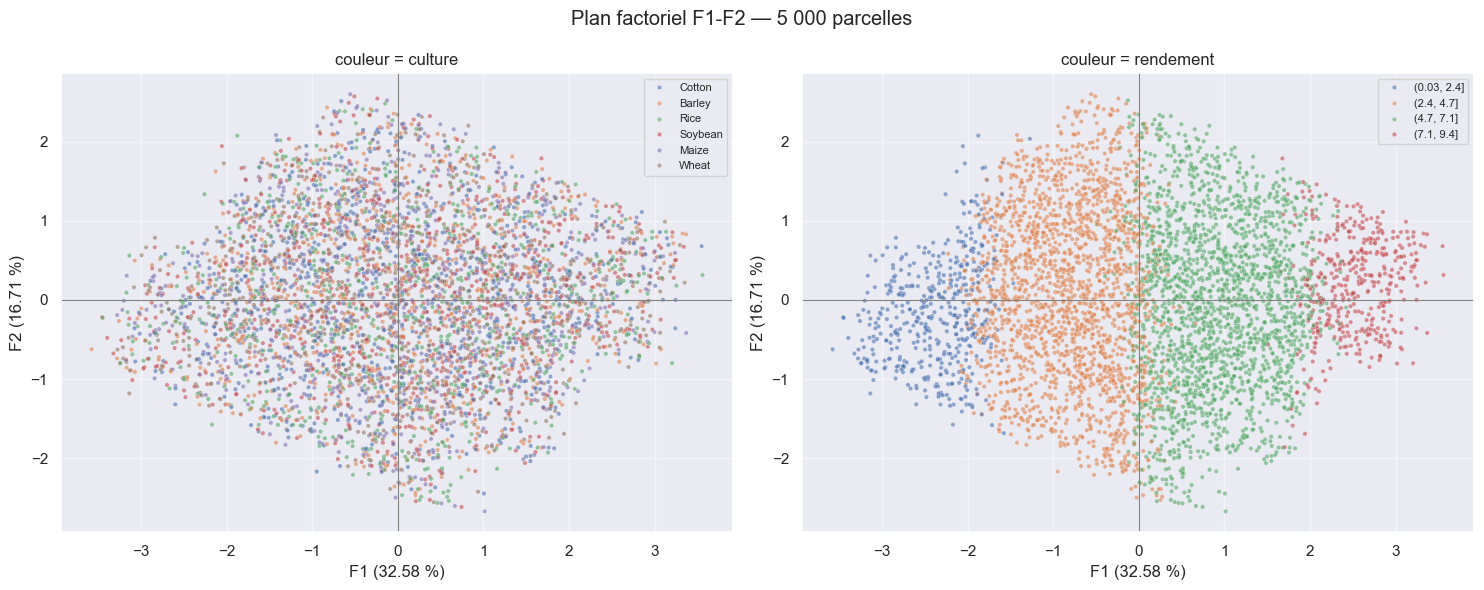

In [16]:
plan_factoriel(
    1, 2,
    [
        (df.loc[idx, "Crop"], "couleur = culture"),
        (pd.cut(df.loc[idx, "Yield_tons_per_hectare"], 4, precision=1), "couleur = rendement"),
    ],
)

**Observations :**

- Nuage compact, sans groupe séparé.
- Aucune séparation visible entre les cultures sur ce plan factoriel.
- Le rendement se lit comme un dégradé le long de F1, sans structure sur F2.

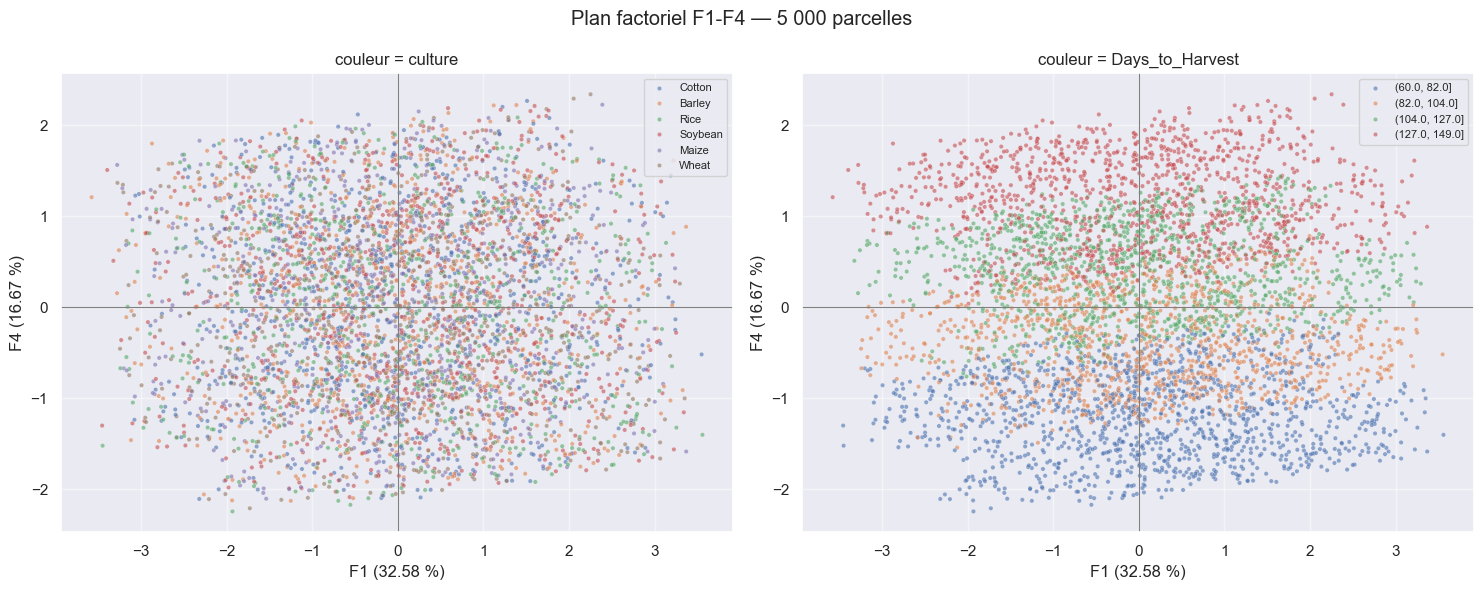

In [17]:
plan_factoriel(
    1, 4,
    [
        (df.loc[idx, "Crop"], "couleur = culture"),
        (pd.cut(df.loc[idx, "Days_to_Harvest"], 4, precision=0), "couleur = Days_to_Harvest"),
    ],
)

**Observations :**

- `Days_to_Harvest` se lit comme un dégradé net le long de F4, conforme à sa corrélation de
  0,91 avec cet axe.
- Aucune séparation visible entre les cultures.


# Conclusion

- F1 est le seul axe qui se détache nettement : 32,6 % de la variance.
- F1 associe surtout rendement, pluie, engrais et irrigation, toutes de même signe.
- Sans la cible, aucun axe ne domine : les variables explicatives sont peu corrélées entre elles.
- `Days_to_Harvest` ne présente pas de relation linéaire notable avec les autres variables ;
  elle est portée par F4, à l'écart de la structure principale.
- Aucun des plans factoriels examinés ne fait apparaître de séparation nette entre les cultures.

L'ACP a donc peu d'intérêt comme étape de réduction de dimension avant modélisation.